# Gate Family Quick Start

Let us create one pulse family that implements two-qubit controlled-phase gates,

$$
\mathrm{CP}(\theta)=\operatorname{diag}(1,1,1,e^{i\theta}),
$$

for several target phases $\theta$. We use `PulseFamilyAnsatz` so the pulse duration and ansatz parameters are smooth functions of the CP phase.

In [11]:
# %pip install -q --progress-bar off rydopt # Uncomment for installation on Colab

import numpy as np
import rydopt as ro
from tqdm import tqdm

First, we choose four target phases between $\pi/4$ and $\pi$ that should be realized by the same family of pulses. Each phase defines one `TwoQubitGate`; the `GateFamily` combines their infidelities during optimization. We leave the single-qubit phase `phi` unspecified, so RydOpt may absorb any accompanying local $Z$ phase.

In [ ]:
target_phases = np.linspace(0.25, 1.0, 4) * np.pi

sampled_gates = [
    ro.gates.TwoQubitGate(
        phi=None,
        theta=phase,
        Vnn=float("inf"),
        decay=0.0,
    )
    for phase in target_phases
]

gate_family = ro.gates.GateFamily(
    fixed_parameter_gates=sampled_gates,
    parameter_values=target_phases,
)

Then we choose a pulse family ansatz. The underlying pulse has constant detuning and a sine-CRAB laser-phase sweep with two coefficients. The `PolynomialPulseMap` uses degrees `[1, 0, 2, 0]`, so the duration is linear in the normalized CP phase $\theta/(2\pi)$, the detuning is phase-independent, and each laser-phase coefficient is quadratic. The Rabi frequency amplitude remains fixed at one.

In [16]:
degrees = [1, 0, 2, 0]  # duration, detuning, laser phase, Rabi amplitude

pulse_map = ro.pulses.PolynomialPulseMap(degrees=degrees)
pulse_family = ro.pulses.PulseFamilyAnsatz(
    detuning_ansatz=ro.pulses.Const(),
    phase_ansatz=ro.pulses.SinCrab(2),
    pulse_map=pulse_map,
)

For multi-start optimization, we provide lower and upper bounds for random pulse-family parameters rather than a single initial guess. The bounds follow the polynomial-map shapes: a quadratic duration coefficient, one constant detuning coefficient, two quadratic laser-phase coefficients, and no trainable Rabi parameters.

In [4]:
min_initial_params = ro.pulses.PulseFamilyParams(
    [0.0, 0.0], [[-1.0]], [[-1.0, -1.0, -1.0], [-1.0, -1.0, -1.0]], [[]]
)
max_initial_params = ro.pulses.PulseFamilyParams(
    [7.0, 7.0], [[1.0]], [[1.0, 1.0, 1.0], [1.0, 1.0, 1.0]], [[]]
)

Now, we optimize the shared pulse-family coefficients with `multi_start_optimize`. The optimizer samples 100 random initial parameter sets within the bounds, runs each candidate for up to 1500 steps, and minimizes the mean infidelity over the four training CP gates.

In [5]:
opt_result_gate_family = ro.optimization.multi_start_optimize(
    gate_family,
    pulse_family,
    min_initial_params,
    max_initial_params,
    tol=1e-4,
    num_initializations=100,
    num_steps=1500,
    num_processes=4,
    return_history=False,
)
optimized_family_params = opt_result_gate_family.params

Started optimization using 4 processes



proc02:   0%|          | 0/1500 [00:00<?, ?it/s]

proc01:   0%|          | 0/1500 [00:00<?, ?it/s]

proc03:   0%|          | 0/1500 [00:00<?, ?it/s]

proc00:   0%|          | 0/1500 [00:00<?, ?it/s]


=== Optimization finished using multi-start Adam ===

Runtime: 80.351 seconds
Gates with infidelity below tol=1.0e-04: 17

Slowest gate:
> infidelity <= tol
PulseFamilyParams(
  duration_params = [6.95318579, 1.82090685],
  detuning_params = [-0.75240648],
  phase_params =    [[-0.2554167 , -2.16580674,  2.50460686],
                     [-3.884383  ,  2.50621009,  0.74456554]],
  rabi_params =     []
)

Fastest gate:
> infidelity <= tol
PulseFamilyParams(
  duration_params = [6.79266051, 2.1407565 ],
  detuning_params = [-0.57870493],
  phase_params =    [[-0.20112563, -1.89653945,  2.48447943],
                     [-3.48280053,  2.76986343,  0.55057671]],
  rabi_params =     []
)
> one-sided bootstrap error on duration: 0.009


Finally, we inspect generated pulses on a finer phase grid. `generate_pulse_ansatz` binds the family ansatz to a target phase, and `generate_pulse_params` evaluates the polynomial map to obtain the corresponding single-pulse parameters. Evaluating phases beyond the four training points checks how well the optimized family interpolates across the CP-gate interval.

In [18]:
phase_values = np.linspace(0.25, 1.0, 13)[:5] * np.pi
infidelity_values = []

for phase in tqdm(phase_values):
    gate = ro.gates.TwoQubitGate(
        phi=None,
        theta=phase,
        Vnn=float("inf"),
        decay=0.0,
    )
    pulse = pulse_family.generate_pulse_ansatz(phase)
    params = pulse_family.generate_pulse_params(optimized_family_params, phase)
    infidelity, _, _ = ro.characterization.analyze_gate(gate, pulse, params, tol=1e-4)
    infidelity_values.append(infidelity)

print(
    "\n".join(
        "\n"
        f"CP phase:                    {phase_over_pi:.2f}π\n"
        f"Gate infidelity:             {infidelity:.4e}"
        for phase_over_pi, infidelity in zip(phase_values / np.pi, infidelity_values)
    )
)

100%|██████████| 5/5 [00:08<00:00,  1.71s/it]


CP phase:                    0.25π
Gate infidelity:             6.9163e-05

CP phase:                    0.31π
Gate infidelity:             1.0835e-04

CP phase:                    0.38π
Gate infidelity:             1.2989e-04

CP phase:                    0.44π
Gate infidelity:             1.0104e-04

CP phase:                    0.50π
Gate infidelity:             7.1173e-05


We can also plot the optimized phase sweeps for the target phases in `gate_family`. The detuning and Rabi panels are hidden because they are fixed or phase-independent in this ansatz.

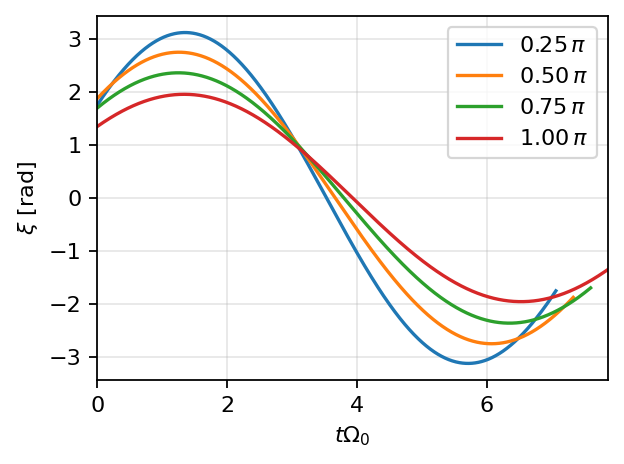

In [7]:
ro.characterization.plot_pulse_family(
    pulse_family,
    optimized_family_params,
    gate_family,
    plot_detuning=False,
    plot_rabi=False,
);